In [1]:
import numpy as np
import matplotlib.pyplot as plt

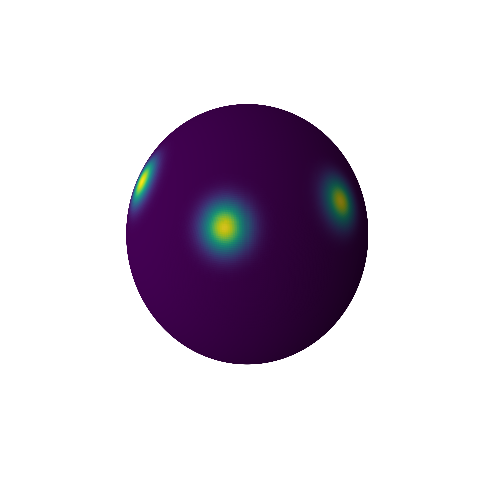

In [2]:
phi, theta = np.mgrid[-np.pi/2:np.pi/2:200j, 0:2*np.pi:400j]
x = np.cos(theta) * np.cos(phi)
y = np.sin(theta) * np.cos(phi)
z = np.sin(phi)

intensity = np.zeros_like(x)

num_vortices = 5
vortex_lat = 30 * np.pi / 180
vortex_radius = 10 * np.pi / 180
vortex_strength = 1.0

for i in range(num_vortices):
    lon0 = i * 2 * np.pi / num_vortices
    lat0 = vortex_lat
    
    # Angular distance between every point and vortex center
    ang_dist = np.arccos(
        np.sin(lat0) * np.sin(phi) +
        np.cos(lat0) * np.cos(phi) * np.cos(theta - lon0)
    )
    
    # Gaussian profile for the vortex
    intensity += vortex_strength * np.exp(-(ang_dist / vortex_radius)**2)

# Plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z, facecolors=plt.cm.viridis(intensity / intensity.max()), rstride=1, cstride=1)
ax.set_box_aspect([1,1,1])
ax.axis('off')
plt.show()


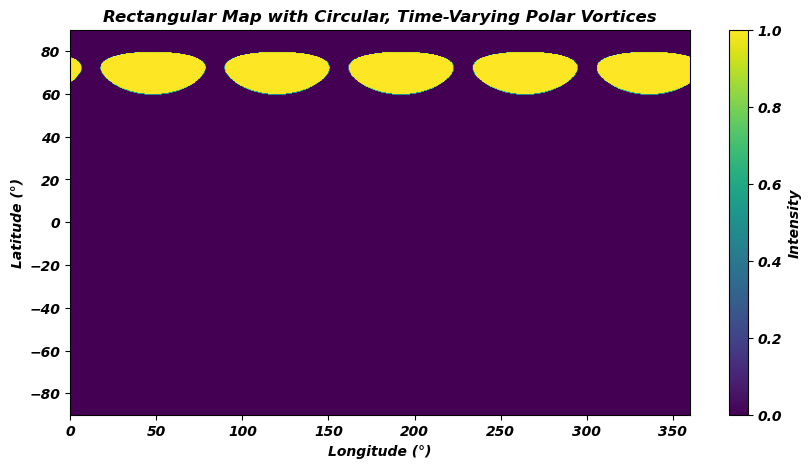

In [24]:
# --- Parameters ---
n_lat, n_lon = 400, 800
bands = [(65, 90), (-90, -65)]
n_vortices = 5
vortex_sigma = 10  # angular size in degrees
lat_center = 78   # latitude where the ring of vortices lives
rotation_period = 30
t = 10
variable_vortices = False

# --- Create lat-lon grid ---
lat = np.linspace(-90, 90, n_lat)
lon = np.linspace(0, 360, n_lon)
lon2d, lat2d = np.meshgrid(np.deg2rad(lon), np.deg2rad(lat))

# --- Initialize scalar field ---
field = np.zeros_like(lat2d)

def add_vortex(field, vlat, vlon, vortex_sigma, amp=1.0):
    dlat = lat2d - np.radians(vlat)
    dlon = lon2d - np.radians(vlon)

    a = np.sin(dlat / 2)**2 + np.cos(np.radians(vlat)) *np.cos(lat2d) * np.sin(dlon / 2)**2
    angular_dist = 2 * np.arcsin(np.sqrt(a))

    mask = (angular_dist <= np.radians(vortex_sigma))
    field[mask] = amp   # or field[mask] += amp if you want accumulation

    return field

# --- Loop through bands and add vortices ---
for (lat1, lat2) in bands:
    lat_center = 70
    vortex_lons = np.linspace(0, 360, n_vortices, endpoint=False)
    vortex_lats = np.full_like(vortex_lons, lat_center)

    # optional phase offsets for time variation
    phase = np.linspace(0, 2*np.pi, n_vortices, endpoint=False)

    for vlat, vlon, ph in zip(vortex_lats, vortex_lons, phase):
        # rotation with time (shift in longitude)
        vlon_t = (vlon + 360 * (t / rotation_period)) % 360

        # time-varying intensity
        amp = 1.0 + 0.3 * np.sin(2 * np.pi * t / rotation_period + ph) if variable_vortices else 1.0

        # add the vortex
        field = add_vortex(field, vlat, vlon_t, vortex_sigma, amp)

# --- Normalize and plot the rectangular map ---
field /= field.max()

plt.figure(figsize=(10, 5))
plt.imshow(field, extent=(0, 360, -90, 90), cmap='viridis', origin='lower', aspect='auto')
plt.xlabel("Longitude (°)")
plt.ylabel("Latitude (°)")
plt.title("Rectangular Map with Circular, Time-Varying Polar Vortices")
plt.colorbar(label="Intensity")
plt.show()

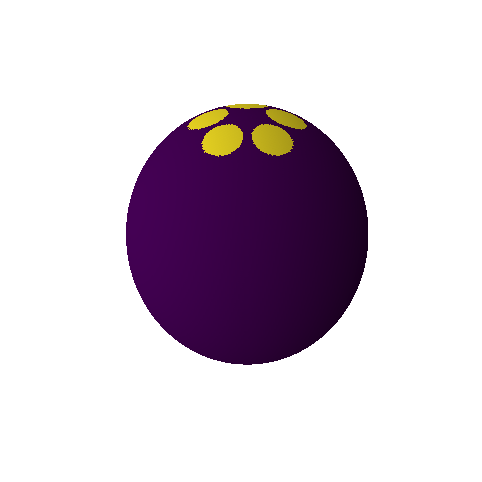

In [25]:
def project_to_sphere(field):
    lon = np.linspace(0, 2*np.pi, field.shape[1])
    lat = np.linspace(-np.pi/2, np.pi/2, field.shape[0])
    lon2d, lat2d = np.meshgrid(lon, lat)
    x = np.cos(lat2d) * np.cos(lon2d)
    y = np.cos(lat2d) * np.sin(lon2d)
    z = np.sin(lat2d)
    return x, y, z

x, y, z = project_to_sphere(field)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, z+0.3, facecolors=plt.cm.viridis(field / field.max()), rstride=2, cstride=2, antialiased=False)
ax.set_box_aspect([1, 1, 1])
ax.axis('off')
plt.show()
